In [6]:
# start by importing the necessary packages
import cv2
import os
import matplotlib.pyplot as plt
import json
import threading
import numpy as np
import matplotlib.cm as cm
from scipy.interpolate import interp1d
from skimage import color, segmentation, measure, morphology, filters
from sklearn.cluster import KMeans
import pandas as pd
import os

# import the detector
from GMMDetector import MaterialDetector
import sys
sys.path.append("../../../src")
from image_container import Image_Container
from Flinder import FlinderDetector

os.environ["OMERO_HOST"] = "100.125.247.59"
os.environ["OMERO_PORT"] = "4064"
os.environ["OMERO_USERNAME"] = "root"
os.environ["OMERO_PASSWORD"] = "omero"


def showImage(img):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 10))
    plt.axis("off")
    plt.imshow(img)

image_container = Image_Container()

In [7]:
def whitebalance(image):
    # return image
    result = image.astype(np.float32)
    quantized = (image // 8) * 8
    brightness = quantized.sum(axis=2)
    mask = brightness > 30
    filtered = quantized[mask]
    
    colors_as_int = (filtered[:, 0].astype(np.int32) << 16) | (filtered[:, 1].astype(np.int32) << 8) | filtered[:, 2].astype(np.int32)
    
    counts = np.bincount(colors_as_int)
    most_common_int = np.argmax(counts)
    
    color = np.array([
        (most_common_int >> 16) & 0xFF,
        (most_common_int >> 8) & 0xFF,
        most_common_int & 0xFF
    ], dtype=np.float32)
    
    avg_gray = (color[0] + color[1] + color[2]) / 3.0
    scale_r = avg_gray / color[0] if color[0] > 0 else 1.0
    scale_g = avg_gray / color[1] if color[1] > 0 else 1.0
    scale_b = avg_gray / color[2] if color[2] > 0 else 1.0
    # print(f"Most common color: RGB({color[0]}, {color[1]}, {color[2]})")
    # print(f"Scale factors: R={scale_r:.3f}, G={scale_g:.3f}, B={scale_b:.3f}")
    result[:, :, 0] *= scale_r
    result[:, :, 1] *= scale_g
    result[:, :, 2] *= scale_b

    result = np.clip(result, 0, 255)
    return result.astype(np.uint8)

def greyscale(image):
    return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [8]:
# Define calibration data as a dict (same format as Flinder's calibration.dat)
# Columns: thickness/layers, k, b, g, r, k_error, b_error, g_error, r_error
#
# You can get these values from:
#   - Flinder's calibration.dat files
#   - Your own measurements of known-thickness flakes
#   - For a single known color: just one row with your target + error


calibration = {
    'thickness': [1],
    'k':         [161],
    'b':         [166],
    'g':         [162],
    'r':         [158],
    'k_error':   [6],
    'b_error':   [5],
    'g_error':   [6],
    'r_error':   [6],
    'number_of_intervals': 1,
}

config = {
    'use_channels': {'k': True, 'b': True, 'g': True, 'r': True},
    'blur_size': 5,
    'median_blur_size': 7,
    'mask_median_blur_size': 5,
    'min_area': 200,
    'criteria': {
        'k_std': {'max': 15},
        'b_std': {'max': 15},
        'g_std': {'max': 15},
        'r_std': {'max': 15},
        'area_perimeter_ratio': {'min': 0.05, 'max': 1.0},
        'aspect_ratio': {'min': 1.0, 'max': 6.0},
    }
}

# Compute mask values using Flinder's interpolation pipeline
mask_values_list = FlinderDetector.compute_mask_values(calibration)

print("Computed mask values per interval:")
for i, mv in enumerate(mask_values_list):
    print(f"\n  Interval {i}:")
    for ch in ['k', 'b', 'g', 'r']:
        print(f"    {ch.upper()}: [{mv[ch]['min']}, {mv[ch]['max']}]")


Computed mask values per interval:

  Interval 0:
    K: [155, 167]
    B: [161, 171]
    G: [156, 168]
    R: [152, 164]


Running Flinder detection algorithm...
Found 9 flakes

Flake 0:
  Thickness interval: 0
  Area: 282 px
  Aspect ratio: 2.01
  KBGR median: (163, 162, 163, 162)
  KBGR std: (1.5, 1.9, 2.6, 2.2)

Flake 1:
  Thickness interval: 0
  Area: 207 px
  Aspect ratio: 1.86
  KBGR median: (163, 162, 163, 162)
  KBGR std: (1.0, 1.8, 1.7, 2.1)

Flake 2:
  Thickness interval: 0
  Area: 240 px
  Aspect ratio: 1.24
  KBGR median: (164, 162, 165, 162)
  KBGR std: (1.0, 2.0, 1.9, 2.2)

Flake 3:
  Thickness interval: 0
  Area: 275 px
  Aspect ratio: 1.09
  KBGR median: (164, 162, 165, 162)
  KBGR std: (1.1, 1.9, 2.0, 2.2)

Flake 4:
  Thickness interval: 0
  Area: 2380 px
  Aspect ratio: 1.43
  KBGR median: (162, 163, 161, 162)
  KBGR std: (6.0, 2.3, 8.0, 5.4)

Flake 5:
  Thickness interval: 0
  Area: 21677 px
  Aspect ratio: 1.30
  KBGR median: (161, 166, 161, 160)
  KBGR std: (1.8, 2.1, 2.6, 2.6)

Flake 6:
  Thickness interval: 0
  Area: 408 px
  Aspect ratio: 4.11
  KBGR median: (162, 168, 160, 163)
  K

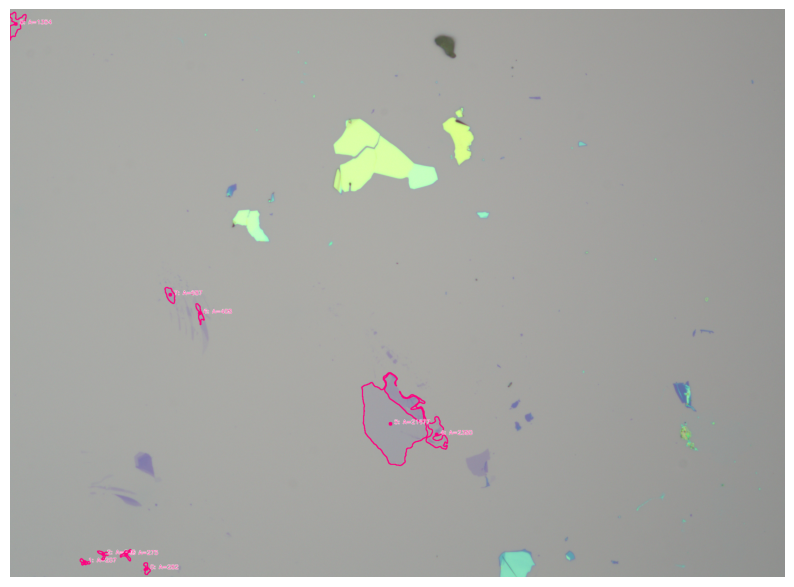

In [10]:
# Test the Flinder detector with calculated mask values
test_image_wb_bgr = whitebalance(cv2.imread("images/image4.png", cv2.IMREAD_COLOR))

# Create detector instance (config dict defined in cell above)
detector = FlinderDetector(config, debug=False)

# Detect flakes
print("Running Flinder detection algorithm...")
flakes = detector.detect_flakes(test_image_wb_bgr, mask_values_list)
print(f"Found {len(flakes)} flakes")

# Visualize results
vis_image = detector.visualize_flakes(test_image_wb_bgr, flakes)

# Print details of detected flakes
for idx, flake in enumerate(flakes):
    stats = flake['stats']
    print(f"\nFlake {idx}:")
    print(f"  Thickness interval: {flake['interval_idx']}")
    print(f"  Area: {stats['area']:.0f} px")
    print(f"  Aspect ratio: {stats['aspect_ratio']:.2f}")
    print(f"  KBGR median: ({stats['k_median']:.0f}, {stats['b_median']:.0f}, "
          f"{stats['g_median']:.0f}, {stats['r_median']:.0f})")
    print(f"  KBGR std: ({stats['k_std']:.1f}, {stats['b_std']:.1f}, "
          f"{stats['g_std']:.1f}, {stats['r_std']:.1f})")

showImage(vis_image)


Running Flinder detection algorithm...
Found 9 flakes

Displaying visualization for image4.png:


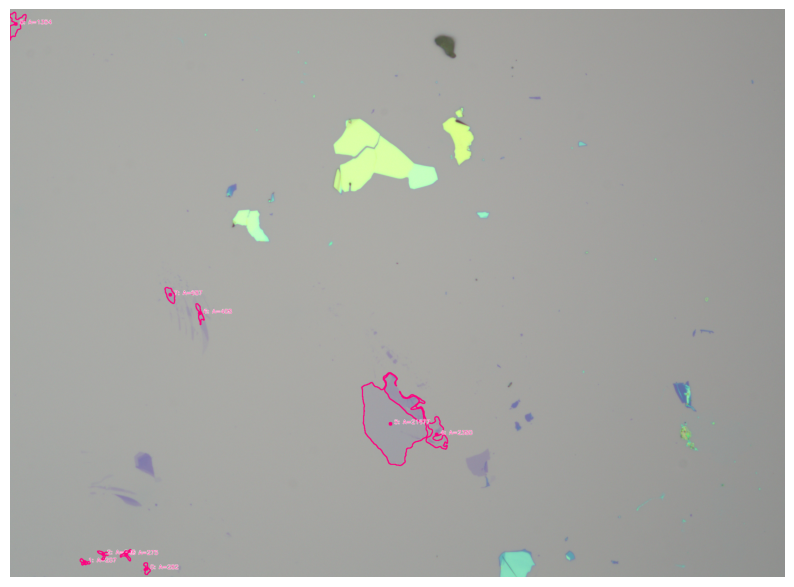

Running Flinder detection algorithm...
Found 10 flakes

Displaying visualization for image5.png:


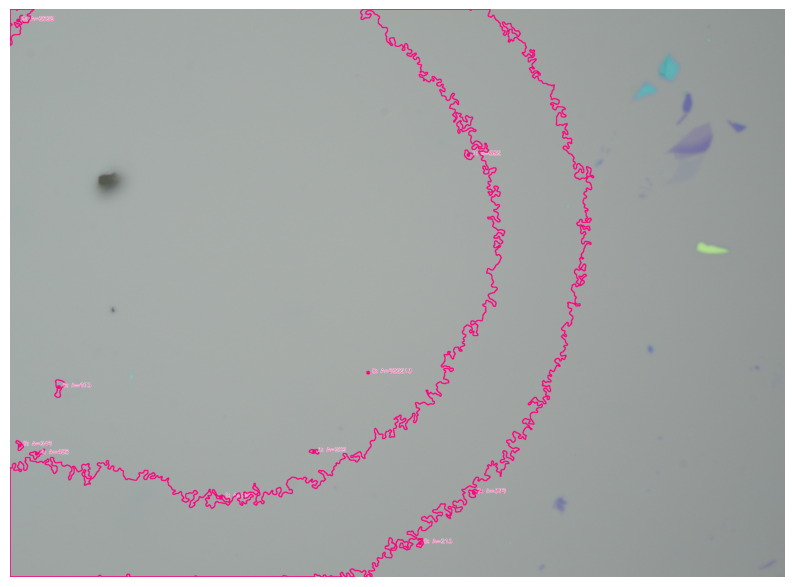

Running Flinder detection algorithm...
Found 53 flakes

Displaying visualization for image6.png:


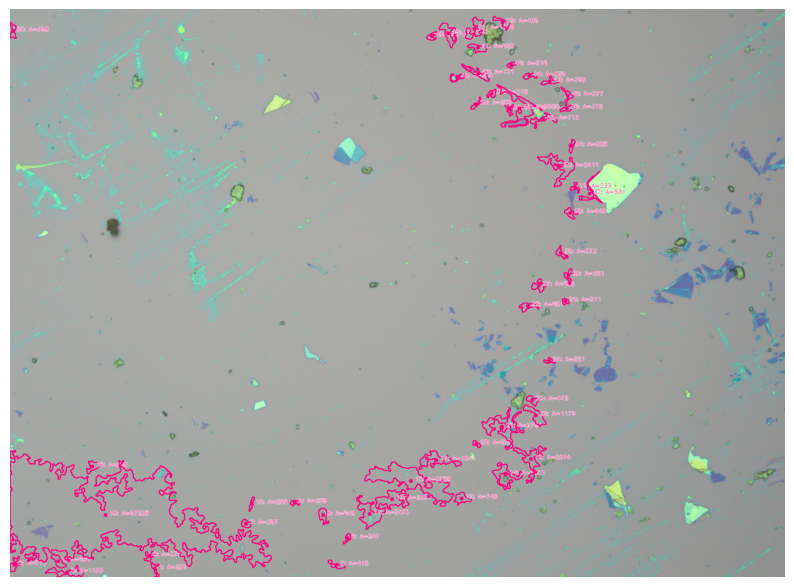

Running Flinder detection algorithm...
Found 15 flakes

Displaying visualization for image7.png:


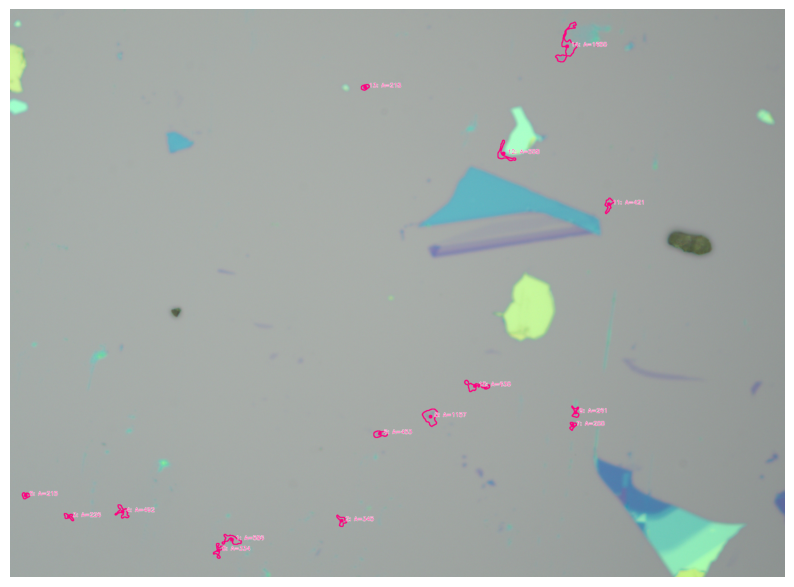

In [ ]:
# Process and visualize images 4-7 on every run
images_dir = "images"
image_numbers = [4, 5, 6, 7]

# Process each image
for img_num in image_numbers:
    image_path = os.path.join(images_dir, f"image{img_num}.png")
    image_bgr = cv2.imread(image_path, cv2.IMREAD_COLOR)

    
    # Convert BGR to RGB for display
    image = whitebalance(image_bgr)
    
    # Detect flakes
    print("Running Flinder detection algorithm...")
    flakes = detector.detect_flakes(image, mask_values_list, min_area=200)
    print(f"Found {len(flakes)} flakes")
    
    # Visualize results on original image (convert to BGR for visualization function)
    vis_image= detector.visualize_flakes(image, flakes)
    
    # # Print details of detected flakes
    # for idx, flake in enumerate(flakes):
    #     stats = flake['stats']
    #     print(f"\nFlake {idx}:")
    #     print(f"  Thickness interval: {flake['interval_idx']}")
    #     print(f"  Area: {stats['area']:.0f} px")
    #     print(f"  Aspect ratio: {stats['aspect_ratio']:.2f}")
    #     print(f"  KBGR median: ({stats['k_median']:.0f}, {stats['b_median']:.0f}, "
    #           f"{stats['g_median']:.0f}, {stats['r_median']:.0f})")
    #     print(f"  KBGR std: ({stats['k_std']:.1f}, {stats['b_std']:.1f}, "
    #           f"{stats['g_std']:.1f}, {stats['r_std']:.1f})")
    
    # Display visualization
    print(f"\nDisplaying visualization for image{img_num}.png:")
    showImage(vis_image)
    plt.show()